# cfd-perf -- Get Started

Minimal notebook: define your mesh and pilot data, pick an optimization
mode, and get scaling figures immediately.

```bash
cd tools/cfd-perf && pip install -e ".[dev]"
```

| Solver type          | Approx FLOP per cell per iteration |
| -------------------- | ----------------------------------- |
| SIMPLE (steady RANS) | 2,000 – 5,000                       |
| PISO (transient)     | 3,000 – 8,000                       |
| LES                  | 5,000 – 15,000                      |
| Implicit + multigrid | 10,000 – 30,000                     |


FLOPS for one core of the machine: 20 GFLOP/s

--> Time per ite for one core = (nb of cells * FLOP per cell) / FLOPS of the machine
--> Time per ite = time above * cores

## 1. Input parameters

Edit the cells below with your own mesh metadata and pilot measurements.

In [ ]:
from pathlib import Path
import sys
import pandas as pd

PLOTTING_PATH = str(Path("../../scripts/post/plot").resolve())
if PLOTTING_PATH not in sys.path:
    sys.path.insert(0, PLOTTING_PATH)

# ---- Mesh: dict or one-row DataFrame ----
mesh_data = {
    "num_cells": 200_000_000,
    "num_faces": 600_000_000,
    "cell_type_distribution": {"hex": 0.78, "prism": 0.14, "tet": 0.06, "pyramid": 0.02},
}

# ---- Pilot: DataFrame (or dict with "points") + n_iterations ----
# --> Passer l'initialisation du calcul + save check point. = faire une iteration.
# --> Relance à partir de la sauvegarde pour 32,64,128... pour 100 iterations
# --> Dans le python, il suffit de faire une fonction getProcs pour avoir le nombre de coeurs et getTimePerIter et getPeakRamTotal pour avoir le temps par iteration et la memoire max.
# A recup depuis les logs ou slurm commandes. Par ex: scontrol show job <jobid> ou sacct -j <jobid> --format=JobID,JobName%20,Partition,AllocNodes,AllocCPUS,MaxRSS ou sacct -j <jobid> --format=JobID,MaxRSS,MaxVMSize,Elapsed or seff <jobid>
# --> On parcourt les différents répertoires et on ajoute au df.
pilot_df = pd.DataFrame([
    {"cores": 32, "time_per_iter_s": 120, "peak_ram_total_gb": 140.0},
])
n_iterations = 20_000

# ---- Optimization settings ----
opt_kwargs = {
    "mode": "efficiency",
    "max_efficiency_loss": 0.3,
    "cores_max": 512,
    "stride": 32,
}
# Optional: opt_kwargs["deadline_hours"] = 6.0  # when mode == "deadline"

# Output path for the figure
out_dir = Path("demo_output")
out_dir.mkdir(exist_ok=True)
scaling_out = out_dir / "scaling.png"

## 2. Run analysis & optimization

Nothing to edit below -- just run the cells.

In [2]:
import cfd_perf
from cfd_perf.io.display import print_fit_result, print_optimization_result
from cfd_perf.constraints.config import HardConstraints

pilot = cfd_perf.pilot_from_data(pilot_df, n_iterations=n_iterations)
mesh = cfd_perf.mesh_from_data(mesh_data, pilot_baseline=pilot.baseline)
params = cfd_perf.fit_beta(pilot)
print_fit_result(params, pilot)

constraints = HardConstraints(min_cells_per_core=100_000, min_ram_per_core_gb=0.5)
result = cfd_perf.optimize(
    mesh, pilot, params,
    constraints=constraints,
    **opt_kwargs,
)
print_optimization_result(result)

       Scaling Model Fit       
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Property        ┃     Value ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Beta            │  0.250000 │
│ Source          │     fixed │
│ Baseline cores  │        32 │
│ Baseline T/iter │ 120.000 s │
│ Iterations      │    20,000 │
│ Pilot points    │         1 │
└─────────────────┴───────────┘

              Pilot Data              
┏━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Cores ┃ T/iter (s) ┃ Peak RAM (GB) ┃
┡━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│    32 │    120.000 │         140.0 │
└───────┴────────────┴───────────────┘

╭────────────────────────────────────── Optimal Configuration (EFFICIENCY) ───────────────────────────────────────╮
│ Cores:           64                                                                                             │
│ Time / iter:     75.000 s                                                                                       │
│ Total runtime:   416.67 h                                                                                       │
│ Speedup:         1.60x                                                                                          │
│ Efficiency:      80.0%                                                                                          │
│ Eff. loss:       20.0%                                                                                          │
│ RAM total:       140.0 GB                                                                                       │
│ RAM / core:      2.19 GB                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                 Accepted Candidates (2)                                 
┏━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━┓
┃ Cores ┃ T/iter (s) ┃ Runtime (h) ┃ Speedup ┃ Eff (%) ┃ Loss (%) ┃ RAM/core (GB) ┃     ┃
┡━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━┩
│    32 │    120.000 │      666.67 │    1.00 │   100.0 │      0.0 │          4.38 │     │
│    64 │     75.000 │      416.67 │    1.60 │    80.0 │     20.0 │          2.19 │ <-- │
└───────┴────────────┴─────────────┴─────────┴─────────┴──────────┴───────────────┴─────┘

              Rejected (14)              
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Cores ┃ Reasons                       ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    96 │ efficiency_loss               │
│   128 │ efficiency_loss               │
│   160 │ efficiency_loss               │
│   192 │ efficiency_loss               │
│   224 │ efficiency_loss               │
│   256 │ efficiency_loss               │
│   288 │ ram_per_core, efficiency_loss │
│   320 │ ram_per_core, efficiency_loss │
│   352 │ ram_per_core, efficiency_loss │
│   384 │ ram_per_core, efficiency_loss │
│   416 │ ram_per_core, efficiency_loss │
│   448 │ ram_per_core, efficiency_loss │
│   480 │ ram_per_core, efficiency_loss │
│   512 │ ram_per_core, efficiency_loss │
└───────┴───────────────────────────────┘

## 3. Scaling figures

          Exported files           
┏━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┓
┃ File        ┃ Format ┃     Size ┃
┡━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━┩
│ scaling.svg │ SVG    │ 175.3 kB │
└─────────────┴────────┴──────────┘

Figure saved to: demo_output/scaling.png


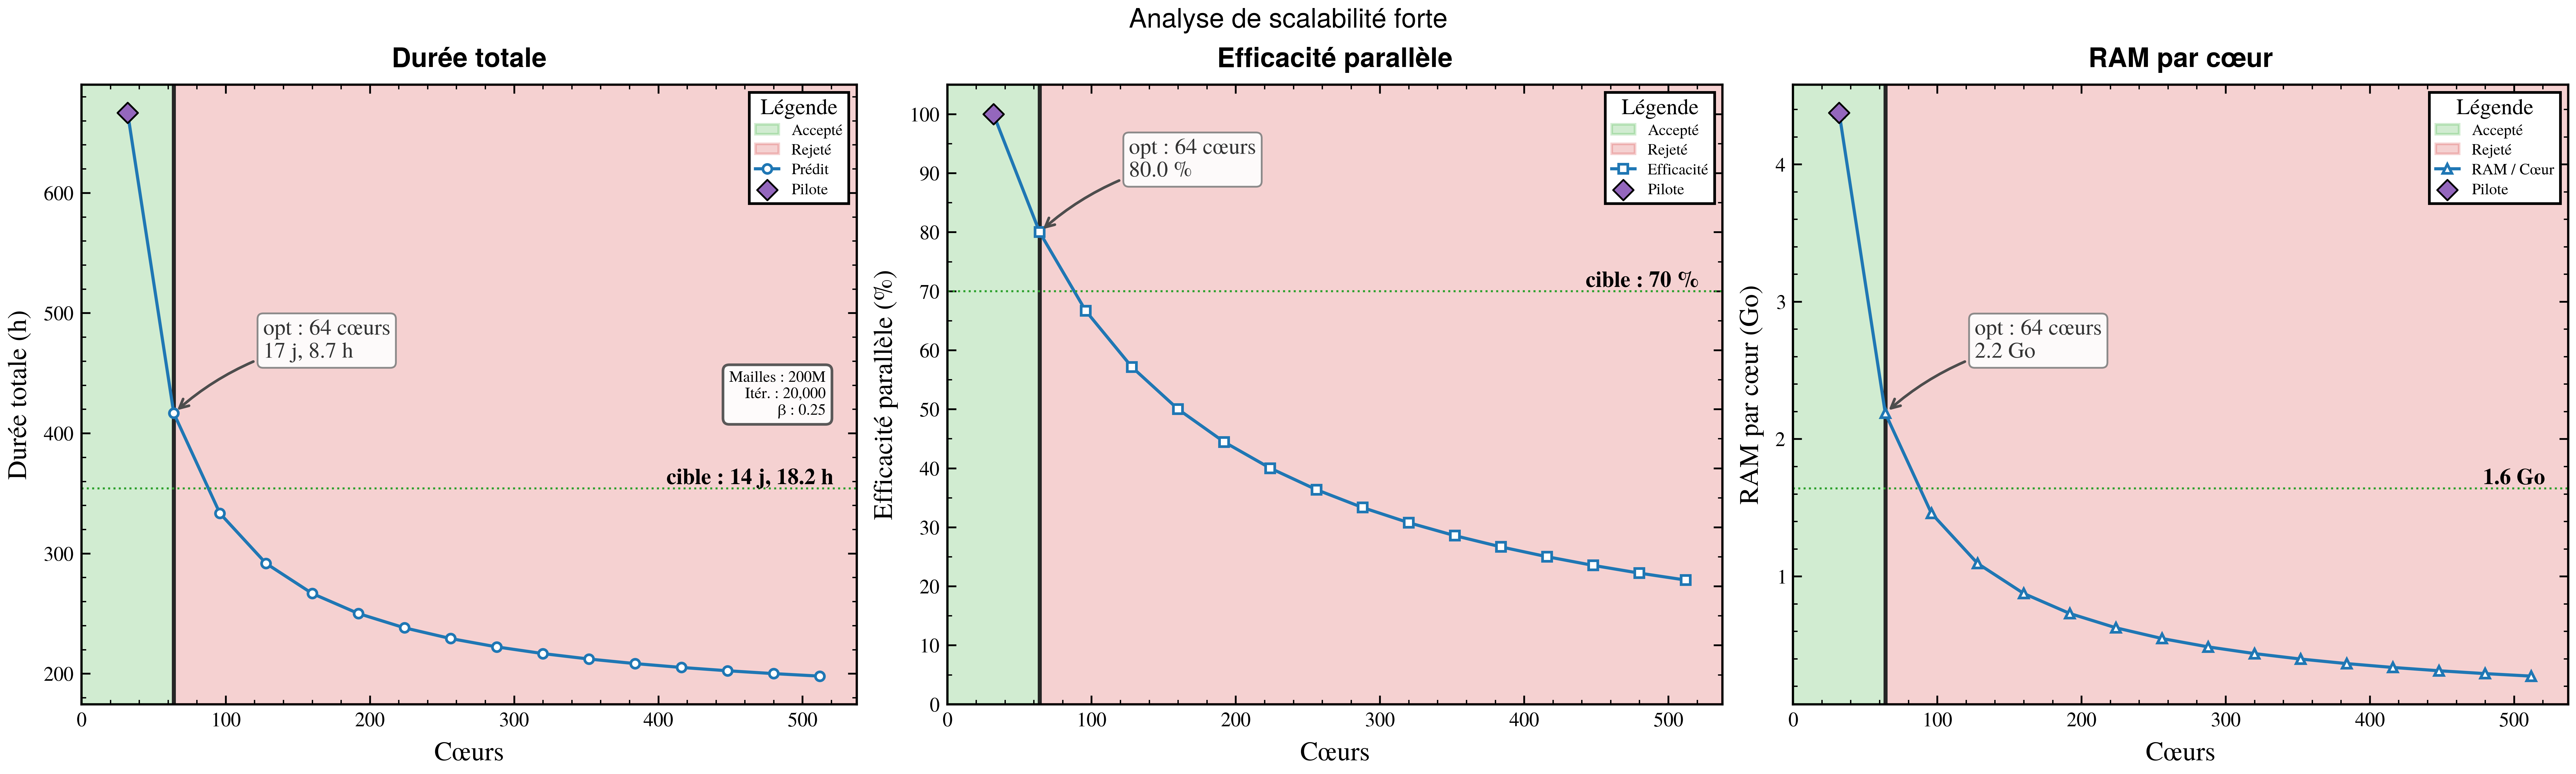

In [3]:
%matplotlib inline
out = cfd_perf.plot_scaling(
    result,
    pilot=pilot,
    mesh=mesh,
    params=params,
    return_figure=True,
)
fig, axes = out if out is not None else (None, None)
if fig is not None:
    from plotting import save_figure
    save_figure(fig, str(scaling_out.with_suffix("")), formats=("svg",), dpi=180, report=True)
print("Figure saved to:", scaling_out)

## 4. Output

The only artifact is the scaling figure (PNG). No JSON/CSV/SLURM exports.

In [4]:
# Figure already saved in previous cell (demo_output/scaling.png)
list(out_dir.iterdir())

[PosixPath('demo_output/scaling.png'), PosixPath('demo_output/scaling.svg')]